# Evidence (Block 1): Stats for AI

**Facundo Bautista Barbera, A01066843**

Analysis of milk sales in the price club channel: how the market is split, how sensitive demand is to price for my manufacturer's top product, and how it could be forecast going forward.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## 0. Which fab did I get?

> *Directions: To know which Manufacturer you work for, take your matricula, add the 8 digits and take the mod 3 plus 1.*

In [2]:
MATRICULA = "A01066843"
digits = [int(c) for c in MATRICULA if c.isdigit()]
print(f"Formula: digit sum = {sum(digits)} -> {sum(digits)} mod 3 + 1 = {sum(digits) % 3 + 1}")

asig = pd.read_excel("../datasets/Evidencia+-+Asignaciones+Fabs.xlsx",
                     sheet_name="2026-08-25T1000_Calificaciones-")
mine = asig[asig["SIS Login ID"].astype(str).str.strip() == MATRICULA]
print(mine.to_string(index=False))

MY_FAB = f"FAB{int(mine['FAB Asignado para Evidencia'].iloc[0])}"
print(f"\nOfficial assignment: {MY_FAB}")

Formula: digit sum = 28 -> 28 mod 3 + 1 = 2
                   Student SIS Login ID  FAB Asignado para Evidencia
Barbera , Facundo Bautista    A01066843                            1

Official assignment: FAB1


## Part 1: Data wrangling and understanding

> *Directions: Do a correct data wrangling/cleaning to prepare the data for descriptive statistics and modelling. You have to check for null values, possible duplicate records (1 same product with 2 product ID, or 1 product ID with 2 different product names). Then you have to do the right data collapsing, possible reshaping, and variable transformations, and come up with the right data structure for analysis.*

### 1.1 Load and first look

In [3]:
df_raw = pd.read_excel("../datasets/DATA_VENTAS.xlsx", sheet_name="datos")
print(df_raw.shape)
print(df_raw.dtypes)
df_raw.head()

(3296, 15)
CORTE                                 str
FABRICANTE                            str
ID                                    str
PRODUCTO                              str
AÑO1                                int64
SEMANA                              int64
MES                                 int64
FECHAW                     datetime64[us]
FECHAM                     datetime64[us]
VENTA_VALOR                       float64
LITROS                              int64
PRECIO_UNITARIO_LITRO             float64
PAQUETES                            int64
PRECIO_UNITARIO_PAQUETE           float64
UNIDADES_EN_PAQUETE                 int64
dtype: object


,CORTE,FABRICANTE,ID,PRODUCTO,AÑO1,SEMANA,MES,FECHAW,FECHAM,VENTA_VALOR,LITROS,PRECIO_UNITARIO_LITRO,PAQUETES,PRECIO_UNITARIO_PAQUETE,UNIDADES_EN_PAQUETE
0,TN,FAB1,1L Sel Des Deslactosada,FAB1_1L Sel Des Deslactosada,2022,14,4,2022-04-04,2022-04-01,"17,492.0000",876,19.9680,73,239.6164,12
1,TN,FAB1,1L Sel Des Deslactosada,FAB1_1L Sel Des Deslactosada,2022,15,4,2022-04-11,2022-04-01,"53,364.9000",2676,19.9420,223,239.3045,12
2,TN,FAB1,1L Sel Des Deslactosada,FAB1_1L Sel Des Deslactosada,2022,16,4,2022-04-18,2022-04-01,"75,747.9600",3828,19.7879,319,237.4544,12
3,TN,FAB1,1L Sel Des Deslactosada,FAB1_1L Sel Des Deslactosada,2022,17,4,2022-04-25,2022-04-01,"73,193.3600",3684,19.8679,307,238.4149,12
4,TN,FAB1,1L Sel Des Deslactosada,FAB1_1L Sel Des Deslactosada,2022,18,5,2022-05-02,2022-05-01,"94,031.1400",4644,20.2479,387,242.9745,12


In [4]:
print("Nulls per column:")
print(df_raw.isna().sum()[lambda s: s > 0])
print(f"\nExact duplicate rows: {df_raw.duplicated().sum()}")
df_raw[df_raw["PRECIO_UNITARIO_LITRO"].isna()][
    ["FECHAW", "FABRICANTE", "ID", "VENTA_VALOR", "LITROS", "PAQUETES"]]

Nulls per column:
PRECIO_UNITARIO_LITRO      3
PRECIO_UNITARIO_PAQUETE    3
dtype: int64

Exact duplicate rows: 0


,FECHAW,FABRICANTE,ID,VENTA_VALOR,LITROS,PAQUETES
1309,2024-04-15,FAB1,Leche Clasica Semi 1 L,0.0000,192,16
1659,2025-01-20,FAB2,Des Light Deslactosada Light 1L,-268.0000,0,0
3268,2025-04-21,FAB3,1L Ent Entera,0.0000,0,0


The only nulls are in the two unit price columns and correspond to weeks where sales were
zero or negative (returns), so the price could not be computed.

### 1.2 Catalog check

I need to verify there is no product with two IDs, or ID with two names. One detail: in this
file `PRODUCTO` carries the manufacturer prefix (`FAB1_...`) and `ID` is the clean name, the
opposite of what you would expect.

In [5]:
print("Names (PRODUCTO) with more than one ID:")
print(df_raw.groupby("PRODUCTO")["ID"].nunique()[lambda s: s > 1])
print("\nIDs with more than one name (PRODUCTO):")
print(df_raw.groupby("ID")["PRODUCTO"].nunique()[lambda s: s > 1])
print("\nIDs present in more than one manufacturer:")
print(df_raw.groupby("ID")["FABRICANTE"].nunique()[lambda s: s > 1])
print(f"\nCatalog: {df_raw['ID'].nunique()} IDs, {df_raw['PRODUCTO'].nunique()} names, "
      f"{df_raw['FABRICANTE'].nunique()} manufacturers")

Names (PRODUCTO) with more than one ID:
Series([], Name: ID, dtype: int64)

IDs with more than one name (PRODUCTO):
Series([], Name: PRODUCTO, dtype: int64)

IDs present in more than one manufacturer:
Series([], Name: FABRICANTE, dtype: int64)

Catalog: 26 IDs, 26 names, 5 manufacturers


The catalog came out clean: every ID has a single name and no product shows up under two manufacturers, so there is nothing to fix here.

### 1.3 From weekly to monthly

The analysis is supposed to be monthly and the data comes in weeks. I drop the weeks with sales or liters at zero or below (8 rows) and collapse everything to month x manufacturer x product using `FECHAM`. Price is computed as `VENTA_VALOR / LITROS`, which is the volume-weighted average price per liter.

In [6]:
df = df_raw[(df_raw["LITROS"] > 0) & (df_raw["VENTA_VALOR"] > 0)].copy()
print(f"Weeks removed for sales/liters <= 0: {len(df_raw) - len(df)}")

monthly = (df.groupby([pd.Grouper(key="FECHAM", freq="MS"), "FABRICANTE", "ID"], as_index=False)
             .agg(revenue=("VENTA_VALOR", "sum"), liters=("LITROS", "sum"),
                  packages=("PAQUETES", "sum"), weeks=("SEMANA", "nunique")))
monthly["price"] = monthly["revenue"] / monthly["liters"]
monthly = monthly.rename(columns={"FECHAM": "date", "FABRICANTE": "fab", "ID": "product"})
monthly["year"] = monthly["date"].dt.year

print(monthly.shape)
print(f"Range: {monthly['date'].min():%Y-%m} to {monthly['date'].max():%Y-%m}")
monthly.head()

Weeks removed for sales/liters <= 0: 8
(709, 9)
Range: 2022-01 to 2025-07


,date,fab,product,revenue,liters,packages,weeks,price,year
0,2022-01-01,FAB1,1L Sele En Selecta Entera,"2,129,869.7400",112848,9404,4,18.8738,2022
1,2022-01-01,FAB1,Leche Clasica Deslactosada 1 L,"4,451,827.6300",248784,20732,4,17.8943,2022
2,2022-01-01,FAB1,Leche Clasica Deslactosada Light 1 L,"2,794,779.4800",143520,11960,4,19.4731,2022
3,2022-01-01,FAB1,Leche Clasica Entera 1 L,"3,400,921.3500",179628,14969,4,18.9331,2022
4,2022-01-01,FAB1,Leche Clasica Light 1 L,"1,158,915.9600",60000,5000,4,19.3153,2022


### 1.4 Market share by year

> *Directions: Provide understanding of the milk category by manufacturer (fab) in terms of a) market share composition by year, and b) sales and price performance over time. Identify the top fabs that make 80% of the market share for the last 12 months. Show relevant descriptive statistics according to your analysis and assumptions.*

In [7]:
share_year = (monthly.pivot_table(index="year", columns="fab", values="revenue", aggfunc="sum")
                     .pipe(lambda t: t.div(t.sum(axis=1), axis=0) * 100)
                     .round(2))
share_year

fab,FAB1,FAB2,FAB3,FAB5,FAB6
year,,,,,
2022,44.6400,21.0300,31.4200,NaN,2.9200
2023,46.4300,22.6500,28.9300,NaN,1.9900
2024,41.2900,20.6900,31.7100,6.3200,0.0000
2025,33.7200,11.6200,27.9800,26.6700,NaN


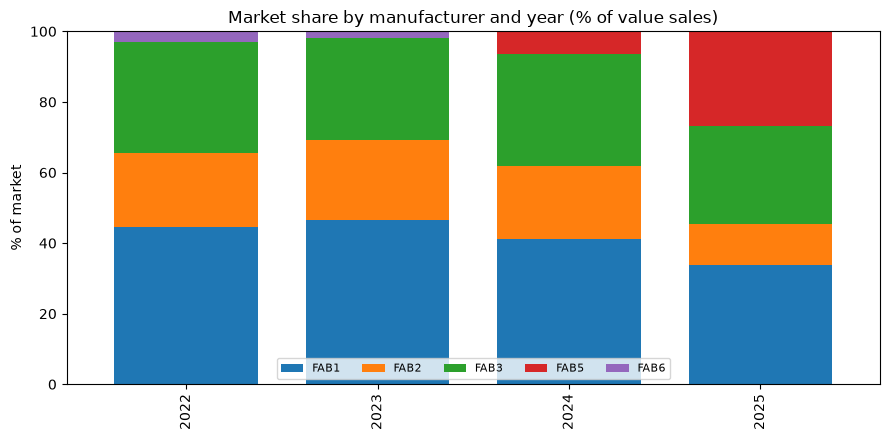

In [8]:
ax = share_year.plot(kind="bar", stacked=True, figsize=(9, 4.5), width=0.75)
ax.set_title("Market share by manufacturer and year (% of value sales)")
ax.set_ylabel("% of market"); ax.set_xlabel("")
ax.legend(title="", ncol=5, loc="lower center", fontsize=8)
plt.tight_layout(); plt.show()

### 1.5 Who makes up 80% of the market? (last 12 months)

In [9]:
last_month = monthly["date"].max()
cutoff = last_month - pd.DateOffset(months=11)
last12 = monthly[monthly["date"] >= cutoff]

pareto = (last12.groupby("fab")["revenue"].sum()
                .sort_values(ascending=False).to_frame("revenue"))
pareto["share_%"] = pareto["revenue"] / pareto["revenue"].sum() * 100
pareto["cum_share_%"] = pareto["share_%"].cumsum()

top80 = pareto[pareto["cum_share_%"].shift(fill_value=0) < 80]
print(f"Window: {cutoff:%Y-%m} to {last_month:%Y-%m}")
print(f"Fabs making 80% of the market: {list(top80.index)}")
pareto.round(2)

Window: 2024-08 to 2025-07
Fabs making 80% of the market: ['FAB1', 'FAB3', 'FAB5']


,revenue,share_%,cum_share_%
fab,,,
FAB1,"255,391,705.2500",35.9300,35.9300
FAB3,"204,099,368.5100",28.7200,64.6500
FAB5,"156,370,728.4400",22.0000,86.6500
FAB2,"94,889,808.9000",13.3500,100.0000


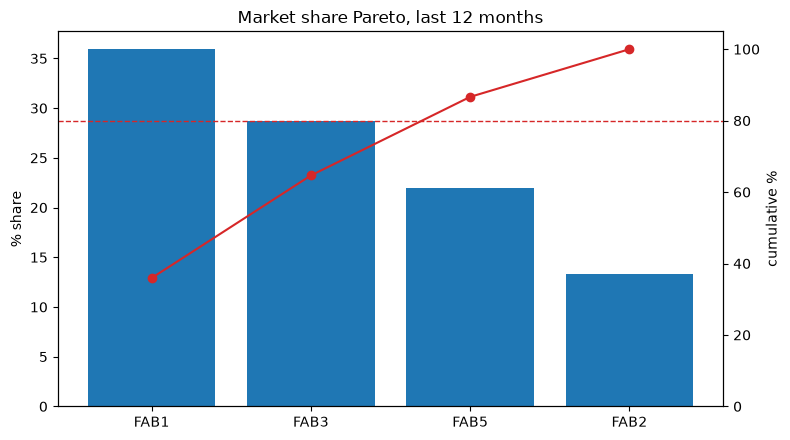

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(pareto.index, pareto["share_%"], color="tab:blue")
ax2 = ax.twinx()
ax2.plot(pareto.index, pareto["cum_share_%"], color="tab:red", marker="o")
ax2.axhline(80, color="tab:red", ls="--", lw=1)
ax2.set_ylim(0, 105)
ax.set_title("Market share Pareto, last 12 months")
ax.set_ylabel("% share"); ax2.set_ylabel("cumulative %")
plt.tight_layout(); plt.show()

### 1.6 Sales and prices over time

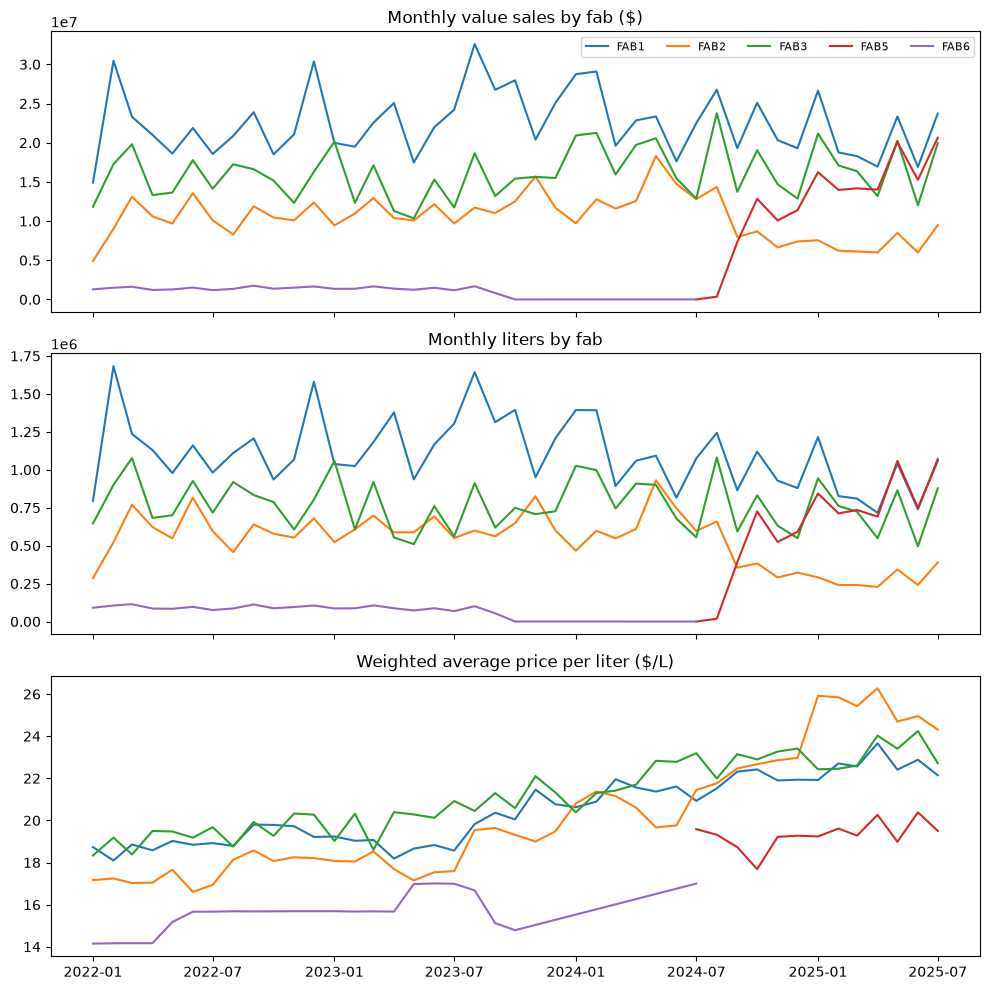

In [11]:
g = monthly.groupby(["date", "fab"])
perf = pd.DataFrame({"revenue": g["revenue"].sum(), "liters": g["liters"].sum()})
perf["price"] = perf["revenue"] / perf["liters"]
perf = perf.reset_index()

fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
titles = ["Monthly value sales by fab ($)", "Monthly liters by fab",
          "Weighted average price per liter ($/L)"]
for metric, ax, title in zip(["revenue", "liters", "price"], axes, titles):
    for fab, gg in perf.groupby("fab"):
        ax.plot(gg["date"], gg[metric], label=fab, lw=1.5)
    ax.set_title(title)
axes[0].legend(ncol=5, fontsize=8)
plt.tight_layout(); plt.show()

In [12]:
desc = perf.groupby("fab")[["revenue", "liters", "price"]].agg(["mean", "std", "min", "max"])
desc.round(2)

revenue                                                 \
                mean            std             min             max   
fab                                                                   
FAB1 22,467,363.2100 4,165,137.8200 14,909,215.9200 32,581,294.0800   
FAB2 10,459,619.8800 2,853,997.4200  4,905,007.1700 18,292,402.8500   
FAB3 16,113,243.8200 3,298,065.4100 10,347,451.5600 23,764,535.9300   
FAB5 12,028,535.6500 6,373,382.8100        235.0000 20,633,808.1300   
FAB6  1,278,838.0600   454,639.4800        204.0000  1,760,655.0900   

             liters                                 price                 \
               mean          std     min      max    mean    std     min   
fab                                                                        
FAB1 1,106,624.0900 233,279.9400  716184  1682580 20.4600 1.5600 18.1000   
FAB2   535,650.7000 174,834.6700  228120   930132 20.1700 2.9000 16.6000   
FAB3   767,438.2300 165,198.0700  496008  1080804 21.1100 1.6800 18.3300   
FAB5   622,989.2300 328,783.6700      12  1058160 19.3100 0.6700 17.6900   
FAB6    82,317.3900  29,540.1700      12   114336 15.6000 0.9100 14.1500   

              
         max  
fab           
FAB1 23.6600  
FAB2 26.2700  
FAB3 24.2400  
FAB5 20.3800  
FAB6 17.0100

My notes (Objective 1): FAB1 (my fab) is the historical leader of the category, but it is on the way down: from 44.6% share in 2022 it rose to 46.4% in 2023, then fell to 41.3% in 2024 and 33.7% in 2025. The interesting part is that the hit is not coming from FAB2 or FAB3 but from FAB5, the private label (Members Mark), which entered in 2024 with 6.3% and by 2025 already holds 26.7%, hurting everyone along the way: FAB2 dropped from 20.7% to 11.6% and FAB6 practically disappeared from the category. The manufacturers making up 80% of the market over the last 12 months are FAB1, FAB3 and FAB5. On price, FAB1 sells at $20.46 per liter on average, below FAB3 ($21.11) and above FAB5 ($19.31), which is consistent with the private label competing on price and gaining share because of it. The time series also show inflation pushing everyone's price up in a similar way, while FAB1's volume stays roughly stable but under pressure since mid 2024.

### 1.7 Correlations

> *Directions: Provide initial correlation analysis to understand important relationship within the data. You have to justify how and why you did this correlation analysis. Explain your results.*

Since the end goal is to estimate price sensitivity, the central relationship to explore is price versus quantity per product. I compute the correlation on logs (`log(liters)` vs `log(price)`) for three reasons: elasticity is defined in percentage changes and that is exactly what the log scale captures, it reduces the weight of extreme values, and it is the same functional form of the model I run in Part 2, so this correlation previews the sign and strength the beta should show. I also check the correlation between the prices of the category's best sellers, to detect possible substitutes (or manufacturers following each other's prices), which helps justify the cross-price elasticity I propose in point 5.

In [13]:
fab_data = monthly[monthly["fab"] == MY_FAB]

corr_table = (fab_data.groupby("product")
              .apply(lambda gg: pd.Series({
                  "n_months": len(gg),
                  "corr_logP_logQ": np.corrcoef(np.log(gg["price"]), np.log(gg["liters"]))[0, 1],
              }), include_groups=False)
              .sort_values("corr_logP_logQ"))
corr_table.round(3)

,n_months,corr_logP_logQ
product,,
Leche Clasica Light 1 L,34.0000,-0.8260
Leche Clasica Deslactosada 1 L,43.0000,-0.4370
1L Sele En Selecta Entera,43.0000,-0.4200
Leche Clasica Extra Deslactosada 1 L,36.0000,-0.3430
Leche Clasica Deslactosada Light 1 L,43.0000,-0.3370
Leche Clasica Entera 1 L,43.0000,-0.0830
Leche Clasica Semi 1 L,27.0000,0.1190
1L Sel Des Deslactosada,40.0000,0.1440


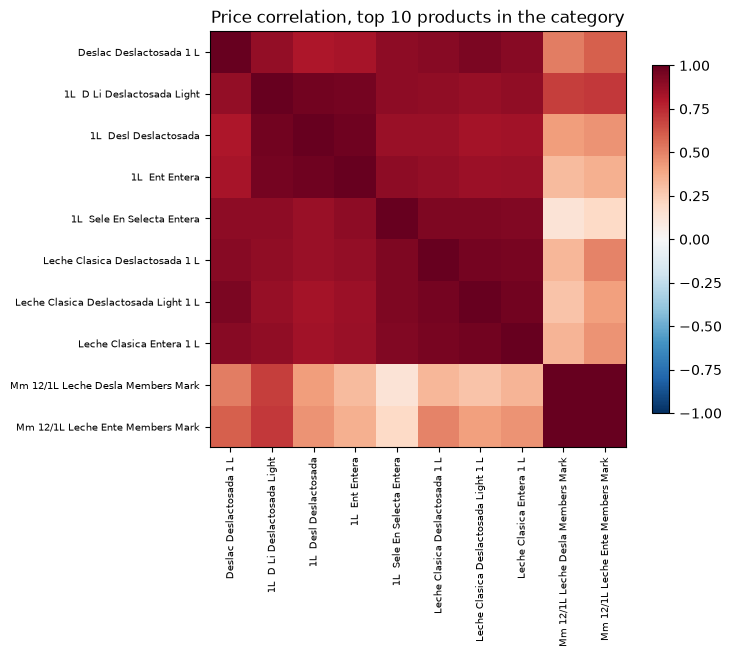

product,Deslac Deslactosada 1 L,1L D Li Deslactosada Light,1L Desl Deslactosada,1L Ent Entera,1L Sele En Selecta Entera,Leche Clasica Deslactosada 1 L,Leche Clasica Deslactosada Light 1 L,Leche Clasica Entera 1 L,Mm 12/1L Leche Desla Members Mark,Mm 12/1L Leche Ente Members Mark
product,,,,,,,,,,
Deslac Deslactosada 1 L,1.0000,0.8800,0.8100,0.8300,0.8900,0.9100,0.9400,0.9100,0.5100,0.6000
1L D Li Deslactosada Light,0.8800,1.0000,0.9600,0.9600,0.9000,0.8900,0.8700,0.8800,0.6900,0.7100
1L Desl Deslactosada,0.8100,0.9600,1.0000,0.9700,0.8600,0.8600,0.8300,0.8400,0.4200,0.4500
1L Ent Entera,0.8300,0.9600,0.9700,1.0000,0.8900,0.8800,0.8500,0.8600,0.3200,0.3600
1L Sele En Selecta Entera,0.8900,0.9000,0.8600,0.8900,1.0000,0.9300,0.9300,0.9300,0.1400,0.2000
Leche Clasica Deslactosada 1 L,0.9100,0.8900,0.8600,0.8800,0.9300,1.0000,0.9500,0.9500,0.3300,0.4900
Leche Clasica Deslactosada Light 1 L,0.9400,0.8700,0.8300,0.8500,0.9300,0.9500,1.0000,0.9600,0.2800,0.4100
Leche Clasica Entera 1 L,0.9100,0.8800,0.8400,0.8600,0.9300,0.9500,0.9600,1.0000,0.3400,0.4500
Mm 12/1L Leche Desla Members Mark,0.5100,0.6900,0.4200,0.3200,0.1400,0.3300,0.2800,0.3400,1.0000,1.0000


In [14]:
top_cat = (last12.groupby("product")["liters"].sum()
                 .sort_values(ascending=False).head(10).index)
price_wide = (monthly[monthly["product"].isin(top_cat)]
              .pivot_table(index="date", columns="product", values="price"))
price_corr = price_wide.corr()

fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(price_corr, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(price_corr)))
ax.set_xticklabels(price_corr.columns, rotation=90, fontsize=7)
ax.set_yticks(range(len(price_corr)))
ax.set_yticklabels(price_corr.index, fontsize=7)
fig.colorbar(im, shrink=0.8)
ax.set_title("Price correlation, top 10 products in the category")
plt.tight_layout(); plt.show()
price_corr.round(2)

My notes (correlations): within FAB1, 6 out of 8 products show the negative price-quantity correlation theory predicts, with *Leche Clasica Light 1 L* the strongest (−0.83), followed by the *Deslactosada* (−0.44) and the *Selecta Entera* (−0.42). The curious detail is that the top product, *Leche Clasica Entera 1 L*, barely shows −0.08, which is an early warning that the simple price-quantity relationship is contaminated by seasonality and trend, that the price-only model in Objective 3 will explain very little, and that the improved model in Objective 6 is exactly what is needed. The price matrix shows very high correlations (0.80 to 0.96) between products from different manufacturers, meaning there is a common component of cost inflation and competitors clearly follow each other's prices; this supports adding cross-price elasticity and trend to the model, but it also warns that putting many competitor prices in at once would cause multicollinearity.

## Part 2: Modeling

### 2.1 My fab's top product (last 12 months)

In [15]:
ranking = (last12[last12["fab"] == MY_FAB].groupby("product")["liters"].sum()
           .sort_values(ascending=False))
print(ranking.to_string())
TOP = ranking.index[0]
print(f"\nTop product for {MY_FAB}: {TOP}")

product
Leche Clasica Entera 1 L                3977472
Leche Clasica Deslactosada 1 L          3880380
Leche Clasica Deslactosada Light 1 L    1910724
1L  Sele En Selecta Entera              1060860
1L  Sel Des Deslactosada                 549144
Leche Clasica Extra Deslactosada 1 L      64080
Leche Clasica Light 1 L                   12456
Leche Clasica Semi 1 L                      936

Top product for FAB1: Leche Clasica Entera 1 L


### 2.2 Direct price elasticity model (price only)

> *Directions: Design and run regression model(s) to estimate price sensitivity (direct price elasticity) for the top product of your manufacturer (fab#). Identify the top product as the product that sold the most for the last 12 months. For this model, only consider the price change as explanatory variable. You have to present the regression output for the model and provide a clear interpretation: parameter estimates (beta coefficients), t-Statistics, pvalues, 95% confidence intervals, and R-square.*

I use the log-log model with price as the only variable:

$$\log(Q_t) = \beta_0 + \beta_1 \log(P_t) + \varepsilon_t$$

The nice thing about this form is that $\beta_1$ is directly the elasticity: the percentage
change in liters when price rises 1%.

In [16]:
top = (monthly[(monthly["fab"] == MY_FAB) & (monthly["product"] == TOP)]
       .sort_values("date")
       .assign(log_liters=lambda d: np.log(d["liters"]),
               log_price=lambda d: np.log(d["price"]))
       .reset_index(drop=True))
print(f"{len(top)} months of history for {TOP}")

model1 = smf.ols("log_liters ~ log_price", data=top).fit()
print(model1.summary())

43 months of history for Leche Clasica Entera 1 L
                            OLS Regression Results                            
Dep. Variable:             log_liters   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                 -0.017
Method:                 Least Squares   F-statistic:                    0.2848
Date:                Sun, 30 Aug 2026   Prob (F-statistic):              0.596
Time:                        21:13:41   Log-Likelihood:                -11.504
No. Observations:                  43   AIC:                             27.01
Df Residuals:                      41   BIC:                             30.53
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
In

In [17]:
ci = model1.conf_int().rename(columns={0: "CI 2.5%", 1: "CI 97.5%"})
out1 = pd.DataFrame({"beta": model1.params, "t": model1.tvalues,
                     "p-value": model1.pvalues}).join(ci)
print(out1.round(4).to_string())
print(f"\nR2 = {model1.rsquared:.4f} | adjusted R2 = {model1.rsquared_adj:.4f}")
print(f"Direct price elasticity: {model1.params['log_price']:.3f}")

             beta       t  p-value  CI 2.5%  CI 97.5%
Intercept 13.8079  7.0323   0.0000   9.8425   17.7733
log_price -0.3497 -0.5336   0.5965  -1.6731    0.9737

R2 = 0.0069 | adjusted R2 = -0.0173
Direct price elasticity: -0.350


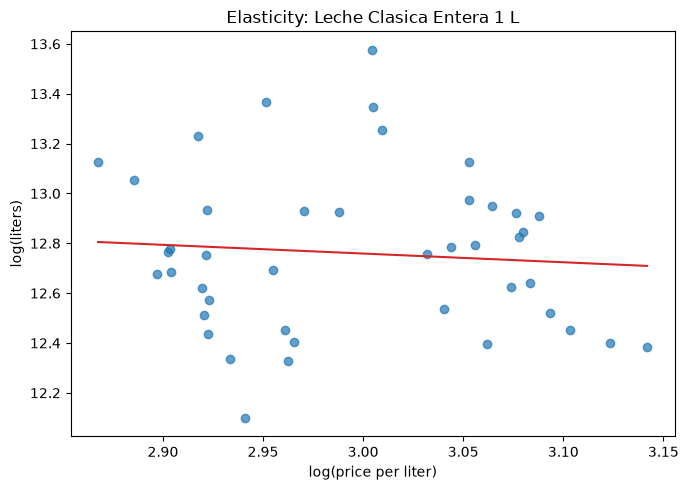

In [18]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(top["log_price"], top["log_liters"], alpha=0.7)
xs = np.linspace(top["log_price"].min(), top["log_price"].max(), 50)
ax.plot(xs, model1.params["Intercept"] + model1.params["log_price"] * xs, color="tab:red")
ax.set_xlabel("log(price per liter)"); ax.set_ylabel("log(liters)")
ax.set_title(f"Elasticity: {TOP}")
plt.tight_layout(); plt.show()

My notes (Model 1): the elasticity comes out at −0.35, meaning that if price rises 1% liters would fall 0.35%, apparently inelastic demand. The problem is that the estimate is not reliable: the t is −0.53 and the p-value 0.597, so the beta sits half a standard error away from zero and is not significant, the confidence interval goes from −1.67 to +0.97 (it includes zero and even positive values, so with this model I cannot even claim the sign), and the R² is 0.007, meaning price alone explains 0.7% of the variation in liters, practically nothing. This is exactly what the −0.08 correlation in section 1.7 anticipated: seasonality and trend, which this model omits, move volume much more than price does, and they also bias the estimate toward zero.

### 2.3 Proposal to improve the model (design only, not run)

> *Directions: Propose how you could improve your model design to incorporate the following factors: cross-price elasticity with other products, seasonality and growth trend. Here you have to explain your model design, not run the model.*

$$\log(Q_t) = \beta_0 + \beta_1 \log(P_t) + \beta_2 \log(P^{comp}_t) + \beta_3 t + \sum_{m=2}^{12} \gamma_m D_{m,t} + \varepsilon_t$$

To incorporate cross-price elasticity I would add the `log(price)` of the direct substitutes, meaning the competitors that came out highly correlated in the 1.7 matrix; each cross beta reads as the % change in my liters when the competitor's price moves 1% (positive implies substitutes, negative complements), and it is better to include only 1 or 2 key competitors or an average competitor price index to avoid multicollinearity problems. For seasonality I would add calendar month dummies with January as base, since milk has a school and vacation pattern and, without the dummies, that variation goes into the error or biases the elasticity if price also moves with the season. Finally, for the growth trend I would add a linear term $t$ (month number since the start) to capture the channel's organic growth, because if both price and volume trend, omitting it creates spurious correlation and a biased elasticity, which is exactly what happened to Model 1.

### 2.4 Model with seasonality and trend

> *Directions: For your model (of the top product), add variables to include the effects of seasonality and growing volume trend. Run the model, show the regression output and interpret the outputs. Did the estimates of direct price elasticity change compared with the previous model? What happened with the statistical significance of the price elasticity? Why do you think the estimates change, and which estimate is the best?*

In [19]:
top["trend"] = np.arange(1, len(top) + 1)
top["month"] = top["date"].dt.month

model2 = smf.ols("log_liters ~ log_price + trend + C(month)", data=top).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:             log_liters   R-squared:                       0.471
Model:                            OLS   Adj. R-squared:                  0.235
Method:                 Least Squares   F-statistic:                     1.990
Date:                Sun, 30 Aug 2026   Prob (F-statistic):             0.0604
Time:                        21:13:42   Log-Likelihood:                 2.0559
No. Observations:                  43   AIC:                             23.89
Df Residuals:                      29   BIC:                             48.54
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         24.1589      3.649      6.

In [20]:
comp = pd.DataFrame({
    "Model 1 (price only)": [model1.params["log_price"], model1.bse["log_price"],
                               model1.tvalues["log_price"], model1.pvalues["log_price"],
                               *model1.conf_int().loc["log_price"], model1.rsquared],
    "Model 2 (+seasonality, +trend)": [model2.params["log_price"], model2.bse["log_price"],
                                       model2.tvalues["log_price"], model2.pvalues["log_price"],
                                       *model2.conf_int().loc["log_price"], model2.rsquared],
}, index=["elasticity", "std error", "t-stat", "p-value", "CI 2.5%", "CI 97.5%", "R2"])
comp.round(4)

,Model 1 (price only),"Model 2 (+seasonality, +trend)"
elasticity,-0.3497,-3.9698
std error,0.6553,1.2642
t-stat,-0.5336,-3.1401
p-value,0.5965,0.0039
CI 2.5%,-1.6731,-6.5554
CI 97.5%,0.9737,-1.3841
R2,0.0069,0.4715


My notes (Model 2 and answers): with seasonality and trend, the elasticity goes from −0.35 to −3.97 and is now significant, with a t of −3.14, a p-value of 0.004, and the whole confidence interval in negative territory (−6.56 to −1.38); the trend comes out at +0.026 (p = 0.002), meaning volume grows around 2.6% per month organically, the month dummies are not individually significant (the closest is June at p = 0.086) but controlling for them cleans up the calendar noise, and the R² goes from 0.007 to 0.47. The estimate changed so much because of omitted variable bias: price and volume rise together over time (inflation on one side, channel growth on the other), and that spurious positive correlation canceled out the real negative relationship in Model 1, pushing the beta toward zero, while once I control for trend and month the price beta compares similar months against each other and isolates the pure effect of the price change. That is also why Model 2's estimate is the better one: it is significant, has the sign theory predicts, and is identified with clean price variation. An elasticity of −3.97 implies very elastic demand, where raising price 1% cuts volume close to 4%, so price increases destroy revenue, which makes sense in a commodity category where the private label (FAB5) is pressing with low prices.

### 2.5 How would I forecast price and sales 24 months out?

> *Directions: Propose how you could forecast price and sales of the top product for the next 24 months. Which types of models you can use to do this. You have to do your own research. Consider not only regression models, but any type of machine learning/AI models.*

There are several ways to forecast the top product's price and sales 24 months ahead, and the choice depends on how much structure you want to impose and how much history is available (in this case, about 43 months). The natural starting point would be to extend the Model 2 I already ran: since it incorporates seasonality and trend, it would be enough to project price under scenarios (for example, our own pricing plan) and use the model to predict liters for each scenario, which is the simplest option and the easiest to explain to the business, although the future price path has to be assumed. If we want the data to speak for itself, the standard for monthly series at this horizon are the classic time series models, either an ARIMA/SARIMA capturing the autocorrelation and seasonality of each series separately, or Holt-Winters exponential smoothing decomposing level, trend and seasonality. One step further are the multivariate models, which I find especially well suited for this problem: a VAR treats price and liters as a system and forecasts both at once, capturing the feedback from price into demand, while a SARIMAX forecasts liters using price as an exogenous variable, which connects directly with the elasticity I already estimated. On the machine learning side, a gradient boosting model (XGBoost or LightGBM) with calendar features and lags, or Prophet to handle multiple seasonalities with little manual tuning, are reasonable alternatives, especially when many products have to be forecast at once, while deep learning models for time series (LSTM, N-BEATS, Transformers) are not justified with 43 months per product, since the overfitting risk is too high for so little history. My concrete proposal would be a SARIMAX for liters with price as an exogenous variable, paired with a univariate SARIMA for the price, because it joins the elasticity I already estimated with the temporal dynamics of the series; before committing to it, I would validate against Holt-Winters and against a boosting model with lags, backtesting over the last 6 to 12 months and comparing MAPE and RMSE, and keep whichever forecasts best out of sample.